# 🚻 Gender based Data Analysis

##### 👩‍🦰 Female

# 📦 Import all Necessary Libraries

In [1]:
import numpy as np               # NumPy is used for solving numerical operations & also working with arrays.

import pandas as pd              # Pandas is used for data cleaning, data analysis, and DataFrame handling.

import matplotlib.pyplot as plt  # Matplotlib is used for creating basic charts and visualizations.

import seaborn as sns            # Seaborn is used for advanced and attractive statistical plots.

import warnings                  # Warnings are used to hide unnecessary warning messages for cleaner output
warnings.simplefilter("ignore")

# 🗂️ Load the Data

In [2]:
dv = pd.read_excel(r"C:\Users\sanja\OneDrive\Desktop\Python_Project\project Data new.xlsx")

# 🔧 Data Cleaning

In [3]:
female_dv = dv[dv["Gender"] == "F"]

In [4]:
female_dv.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
6,1001132,Balk,P00018042,F,18-25,25,1,Uttar Pradesh,Central,Lawyer,Auto,4,23841.0,NaN,NaN
7,1002092,Shivangi,P00273442,F,55+,61,0,Maharashtra,Western,IT Sector,Auto,1,NaN,NaN,NaN


In [5]:
female_dv.shape

(7842, 15)

In [6]:
female_dv.to_excel("female_data.xlsx", index=False)

In [7]:
female_dv.to_csv("female_data.csv", index=False)

In [8]:
female_dv.drop(["Status", "unnamed1"], axis=1, inplace=True)

In [9]:
female_dv.dropna(inplace=True)

In [10]:
female_dv.isnull().sum()

User_ID             0
Cust_name           0
Product_ID          0
Gender              0
Age Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64

In [11]:
female_dv["Marital_Status"] = female_dv["Marital_Status"].replace({
    0: "Single",
    1: "Married"
})

In [12]:
female_dv.rename(columns={"Occupation":"Sector"}, inplace=True)

In [13]:
female_dv.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Sector,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,Single,Maharashtra,Western,Healthcare,Auto,1,23952.00
1,1000732,Kartik,P00110942,F,26-35,35,Married,Andhra Pradesh,Southern,Govt,Auto,3,23934.00
2,1001990,Bindu,P00118542,F,26-35,35,Married,Uttar Pradesh,Central,Automobile,Auto,3,23924.00
6,1001132,Balk,P00018042,F,18-25,25,Married,Uttar Pradesh,Central,Lawyer,Auto,4,23841.00
9,1003650,Ginny,P00031142,F,26-35,26,Married,Andhra Pradesh,Southern,Media,Auto,4,23799.99


In [14]:
female_dv.groupby("Product_Category")["Orders"].sum()

Product_Category
Auto                      162
Beauty                    830
Books                      96
Clothing & Apparel       4648
Decor                     192
Electronics & Gadgets    3682
Food                     4406
Footwear & Shoes         1925
Furniture                 541
Games & Toys              673
Hand & Power Tools         33
Household items           736
Office                    166
Pet Care                  369
Sports Products           655
Stationery                158
Tupperware                121
Veterinary                155
Name: Orders, dtype: int64

# 📊 Data Visualization 

**Bar Plot.**

*This visualization shows the total purchase amount contributed by different age groups among Female customers.*

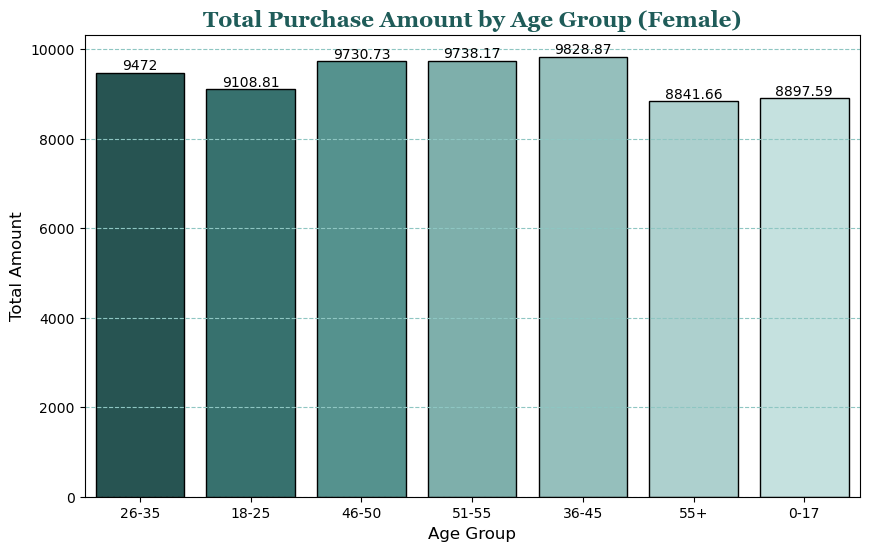

In [23]:
plt.figure(figsize=(10,6))

Palette_1= ["#1F5C59", "#2E7A76", "#4B9C97", "#76B7B2", "#8EC6C2", "#A7D6D3", "#C1E5E3"]

C1 = sns.barplot( x="Age Group", y="Amount", data=female_dv,ci=None, palette=Palette_1, edgecolor="black")

plt.title( "Total Purchase Amount by Age Group (Female)", fontsize=16, fontweight="bold",color="#1F5C59",family="georgia")

plt.xlabel( "Age Group", fontsize=12 )

plt.ylabel("Total Amount", fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.grid(axis="y", linestyle="--", color="#8EC6C2")

for t in C1.containers:
    plt.bar_label(t)
    
plt.show()

**Pie Plot.**

*This pie chart represents the percentage contribution of the top 10 states to total sales generated by female customers.*

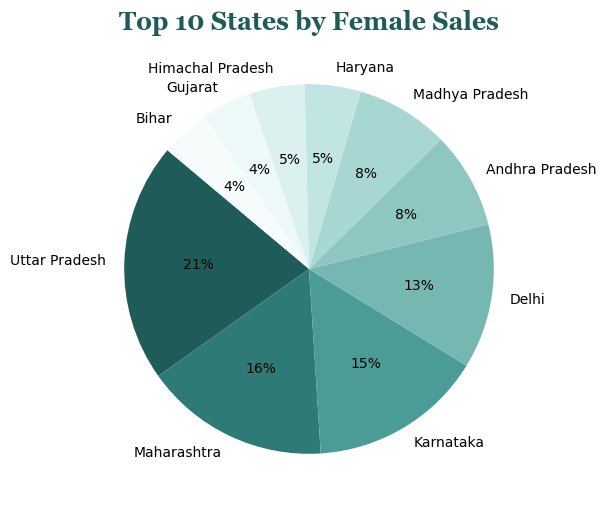

In [25]:
female_state = female_dv.groupby("State", as_index=False)["Amount"].sum().sort_values(by="Amount", ascending=False).head(10)

Palette_2 = ["#1F5C59", "#2E7A76", "#4B9C97", "#76B7B2", "#8EC6C2",  "#A7D6D3", "#C1E5E3", "#DAF1F0", "#EDF9F8", "#F6FCFC"]

plt.figure(figsize=(10,6))

colors = sns.color_palette("crest", len(female_state))

plt.pie(female_state["Amount"], labels=female_state["State"], autopct="%1.f%%", startangle=140, colors=Palette_2)

plt.title( "Top 10 States by Female Sales", fontsize=18, fontweight="bold", color="#1F5C59",family="georgia")

plt.show()

**Bar Plot.**

*This bar chart represents the total number of orders placed by female customers across different age groups.*

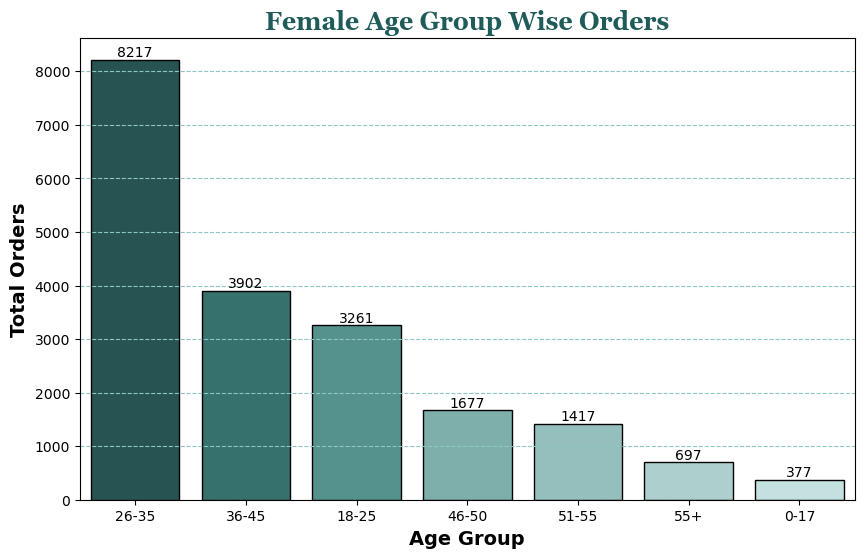

In [28]:
female_age_orders = female_dv.groupby("Age Group", as_index=False)["Orders"].sum().sort_values(by="Orders", ascending=False)

plt.figure(figsize=(10,6))

Palette_3 = ["#1F5C59", "#2E7A76", "#4B9C97", "#76B7B2", "#8EC6C2",  "#A7D6D3", "#C1E5E3"]

C2 = sns.barplot( x="Age Group", y="Orders", data=female_age_orders, palette=Palette_3, edgecolor="Black")

plt.title( "Female Age Group Wise Orders", fontsize=18, fontweight="bold", color="#1F5C59",family="georgia")

plt.xlabel("Age Group", fontsize=14, fontweight="bold")
plt.ylabel("Total Orders", fontsize=14, fontweight="bold")

plt.grid(axis="y", linestyle="--", color="#8EC6C2")

for i in C2.containers:
    C2.bar_label(i)

plt.show()

**Line Plot.**

*This line plot illustrates the total sales amount generated by female customers across different sectors.*

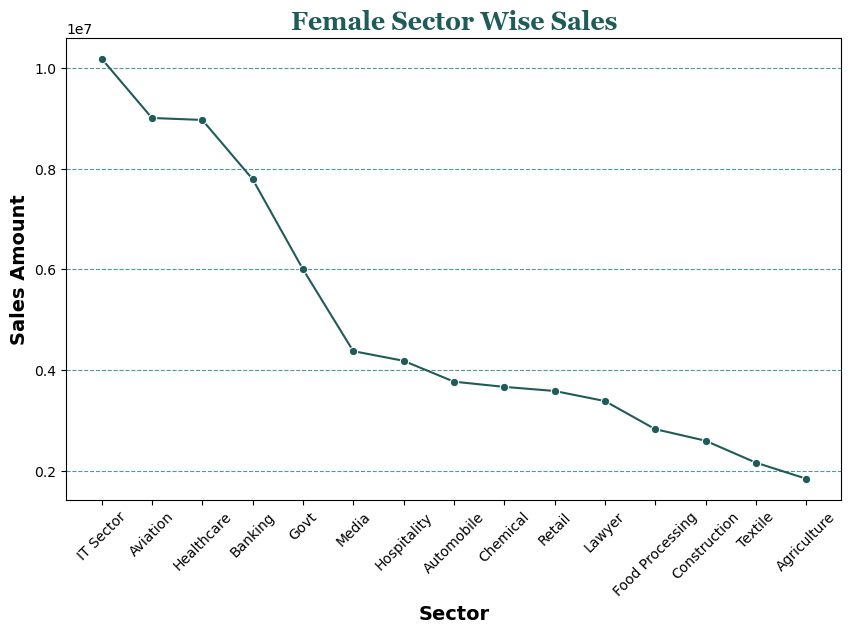

In [31]:
female_sec = female_dv.groupby("Sector", as_index=False)["Amount"].sum().sort_values(by="Amount", ascending=False)

plt.figure(figsize=(10,6))

sns.lineplot( x="Sector", y="Amount", data=female_sec, marker="o", color="#1F5C59")

plt.title( "Female Sector Wise Sales", fontsize=18, fontweight="bold", color="#1F5C59",family="georgia")

plt.xlabel("Sector", fontsize=14, fontweight="bold")
plt.ylabel("Sales Amount", fontsize=14, fontweight="bold")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--",color="#4B9C97")

plt.show()

**Count Plot.**

*A Count plot is used to visualize the top 10 product categories preferred by Male customers based on the number of purchases.*

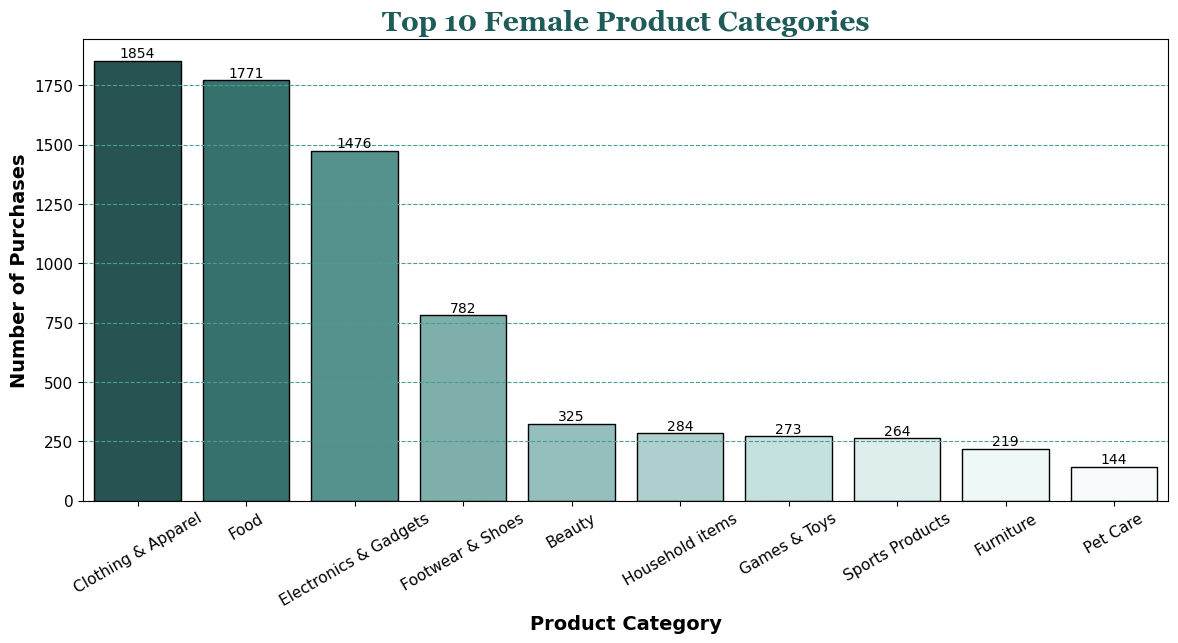

In [32]:
top_10_category = female_dv["Product_Category"].value_counts().sort_values(ascending=False).head(10).index

top_category_data = female_dv[female_dv["Product_Category"].isin(top_10_category)]

plt.figure(figsize=(14,6))

C3 = sns.countplot( x="Product_Category", data=top_category_data, order=top_10_category, palette= Palette_2, edgecolor="Black")

plt.title("Top 10 Female Product Categories",fontsize=20, fontweight="bold", color="#1F5C59",family="georgia")

plt.xlabel( "Product Category", fontsize=14,fontweight="bold")

plt.ylabel( "Number of Purchases", fontsize=14, fontweight="bold")

plt.xticks(rotation=30, fontsize=11)
plt.yticks(fontsize=11)

plt.grid(axis="y", linestyle="--",color="#4B9C97")

for i in C3.containers:
    C3.bar_label(i)

plt.show()